# Quiz Solutions — Magnetic Resonance Image Formation

Worked answers to the MRI image-formation quiz (all 7 questions; the quiz asks for any 5).
Conceptual answers are written out, and several are illustrated with short simulations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Q1 — How is a proton different from an iron filing in a magnetic field?

An **iron filing** is a *ferromagnetic* object: in a field it simply aligns with the field like a
compass needle and stays there — there is no precession and no resonant frequency.

A **proton** has an intrinsic quantum property, **spin** (spin angular momentum $\mathbf{S}$), and
an associated **magnetic moment** $\boldsymbol{\mu}$. The two are linked by the **gyromagnetic
ratio** $\gamma$:
$$\boldsymbol{\mu} = \gamma\,\mathbf{S}.$$
Because the proton carries angular momentum, in a field $\mathbf{B}_0$ it does not just align — it
**precesses** about $\mathbf{B}_0$ (like a spinning top under gravity) at the Larmor frequency
$\omega_0=\gamma B_0$. That precession, and the ability to resonantly tip it with RF, is what makes
MRI possible.

**The two key properties related by the gyromagnetic ratio are the magnetic moment $\mu$ and the
spin angular momentum $S$.**

## Q2 — What principle do RF coils work on, and where does the FID come from?

The receive coils work on **Faraday's law of electromagnetic induction**: a time-varying magnetic
flux through the coil induces a voltage (EMF).

After a static field $B_0$ establishes a net longitudinal magnetization $M_0\hat z$, an **RF pulse**
tips that magnetization into the transverse plane. The transverse magnetization then **precesses**
at the Larmor frequency, sweeping its direction past the receive coil. This rotating transverse
magnetization is a changing flux through the coil, so by Faraday's law it induces an oscillating
voltage — the **Free Induction Decay (FID)**. It *decays* because the transverse magnetization
loses phase coherence ($T_2/T_2^*$).

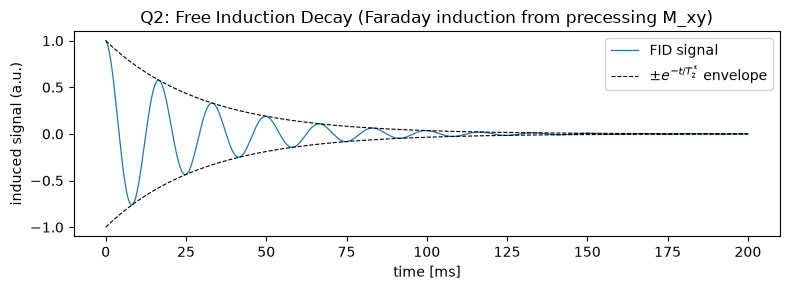

In [2]:
# Illustrative FID: decaying, oscillating transverse signal picked up by the coil
t = np.linspace(0, 0.2, 2000)      # s
f_demo = 60.0                      # demo precession frequency [Hz] (real ~ MHz)
T2star = 0.03                      # effective transverse decay [s]
fid = np.exp(-t / T2star) * np.cos(2 * np.pi * f_demo * t)

plt.figure(figsize=(8, 3))
plt.plot(t * 1e3, fid, color="tab:blue", lw=0.9, label="FID signal")
plt.plot(t * 1e3,  np.exp(-t / T2star), "k--", lw=0.8, label=r"$\pm e^{-t/T_2^*}$ envelope")
plt.plot(t * 1e3, -np.exp(-t / T2star), "k--", lw=0.8)
plt.xlabel("time [ms]"); plt.ylabel("induced signal (a.u.)")
plt.title("Q2: Free Induction Decay (Faraday induction from precessing M_xy)")
plt.legend(); plt.tight_layout(); plt.show()

## Q3 — Why does FID occur, and when would it take (almost) forever to decay?

The FID occurs because the transverse magnetization **dephases**: individual spins precess at
slightly different frequencies (due to $T_2$ spin–spin interactions and $T_2^*$ field
inhomogeneity), so their vector sum — the net transverse signal — shrinks to zero.

The FID would take **infinitely long to decay only if there were no dephasing at all**: a perfectly
homogeneous field *and* no spin–spin relaxation ($T_2, T_2^* \to \infty$). Then every spin stays in
phase and the induced signal never damps.

**Hypothetical disturbance:** if a strong external magnet perturbs the static field *mid-sequence*,
it suddenly makes the field highly inhomogeneous, spins dephase almost instantly, and the FID
**collapses abruptly** at that moment (the envelope drops to zero much faster than normal).

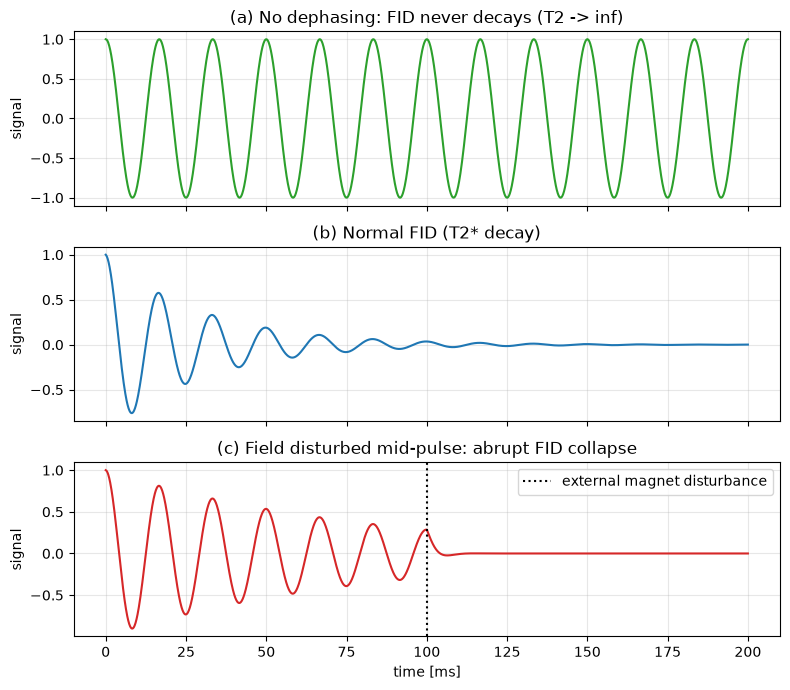

In [3]:
t = np.linspace(0, 0.2, 2000)
f_demo = 60.0

# (a) ideal: no dephasing -> never decays
fid_ideal = np.cos(2 * np.pi * f_demo * t)
# (b) normal FID
fid_norm = np.exp(-t / 0.03) * np.cos(2 * np.pi * f_demo * t)
# (c) external magnet disturbs the field at t = 0.1 s -> abrupt collapse
t_dist = 0.1
env = np.exp(-t / 0.08)
env[t >= t_dist] *= np.exp(-(t[t >= t_dist] - t_dist) / 0.003)   # fast collapse after disturbance
fid_dist = env * np.cos(2 * np.pi * f_demo * t)

fig, ax = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
ax[0].plot(t * 1e3, fid_ideal, color="tab:green"); ax[0].set_title("(a) No dephasing: FID never decays (T2 -> inf)")
ax[1].plot(t * 1e3, fid_norm, color="tab:blue");   ax[1].set_title("(b) Normal FID (T2* decay)")
ax[2].plot(t * 1e3, fid_dist, color="tab:red")
ax[2].axvline(t_dist * 1e3, color="k", ls=":", label="external magnet disturbance")
ax[2].set_title("(c) Field disturbed mid-pulse: abrupt FID collapse"); ax[2].legend()
ax[2].set_xlabel("time [ms]")
for a_ in ax:
    a_.set_ylabel("signal"); a_.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Q4 — Which components of M are measured for a slice, phase relation, and the recovery time constant?

With $B_0$ along **z**, the signal measured for imaging is the **transverse magnetization**
$M_{xy}=(M_x, M_y)$ — the components in the plane perpendicular to $B_0$ (the longitudinal $M_z$ is
not directly detected by the coil).

$M_x$ and $M_y$ are **90° (a quarter cycle) out of phase** with each other — they are the
cosine/sine pair of the same precessing vector:
$$M_x(t)=-M_0 e^{-t/T_2}\sin(\omega_0 t),\qquad M_y(t)=-M_0 e^{-t/T_2}\cos(\omega_0 t).$$

The recovery of the **longitudinal** magnetization $M_z \to M_0$ is governed by the **spin–lattice
relaxation time $T_1$**: $M_z(t)=M_0(1-e^{-t/T_1})$.

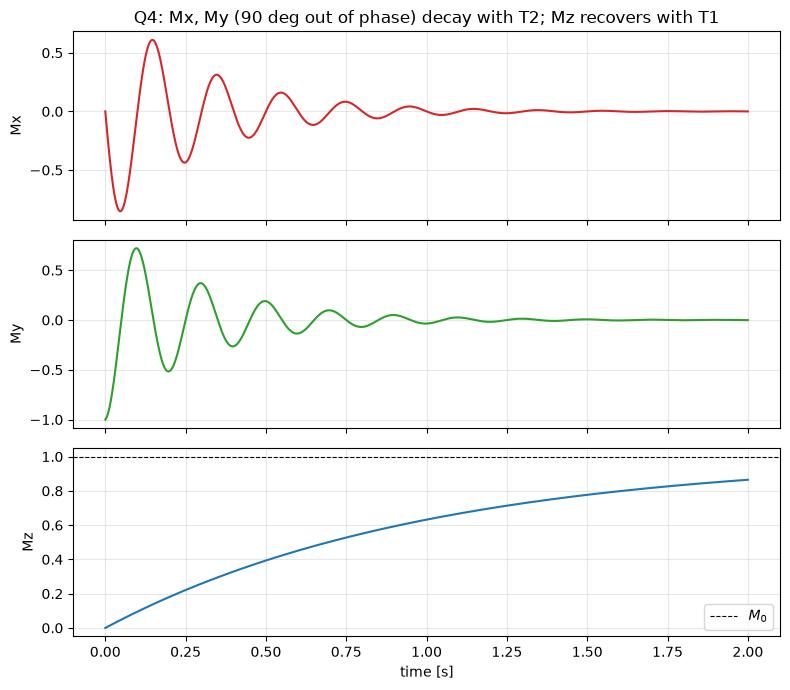

In [4]:
t = np.linspace(0, 2.0, 3000)
M0, T1, T2, w0 = 1.0, 1.0, 0.3, 2 * np.pi * 5.0
Mx = -M0 * np.exp(-t / T2) * np.sin(w0 * t)
My = -M0 * np.exp(-t / T2) * np.cos(w0 * t)
Mz =  M0 * (1 - np.exp(-t / T1))

fig, ax = plt.subplots(3, 1, figsize=(8, 7), sharex=True)
ax[0].plot(t, Mx, "tab:red");   ax[0].set_ylabel("Mx"); ax[0].set_title("Q4: Mx, My (90 deg out of phase) decay with T2; Mz recovers with T1")
ax[1].plot(t, My, "tab:green"); ax[1].set_ylabel("My")
ax[2].plot(t, Mz, "tab:blue");  ax[2].set_ylabel("Mz"); ax[2].set_xlabel("time [s]")
ax[2].axhline(M0, color="k", ls="--", lw=0.8, label="$M_0$"); ax[2].legend()
for a_ in ax:
    a_.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Q5 — The FID is the solution to the ______ equations; which rate constant governs permanent transverse decay?

The FID of a precessing proton is the solution to the **Bloch equations**.

The relaxation constant that governs the **permanent/irreversible decay of signal amplitude in the
plane normal to $B_0$** (the transverse plane) is the **spin–spin relaxation time $T_2$**. (The
faster, partly *reversible* decay from field inhomogeneity is $T_2^*$; the irreversible part is
$T_2$.) $T_1$, by contrast, governs longitudinal recovery.

## Q6 — How is resonance frequency related to $B_0$? Name the equation and its use in slice selection.

The resonance (precession) frequency is **proportional to the field strength** through the
**Larmor equation**:
$$\omega_0 = \gamma B_0 \qquad\text{or}\qquad f_0 = \frac{\gamma}{2\pi}B_0.$$

**Slice selection:** apply a **longitudinal gradient $G_z$** so the field varies with position,
$B(z)=B_0+G_z z$. Then each slice has its own resonance frequency $f(z)=\frac{\gamma}{2\pi}(B_0+G_z z)$.
Transmitting an RF pulse containing a **band of frequencies** $f_0\pm BW/2$ excites only the slab
whose $f(z)$ lies in that band. The slice thickness is $\Delta z = BW/[(\gamma/2\pi)G_z]$ and the
slice position is set by the center frequency $f_0$.

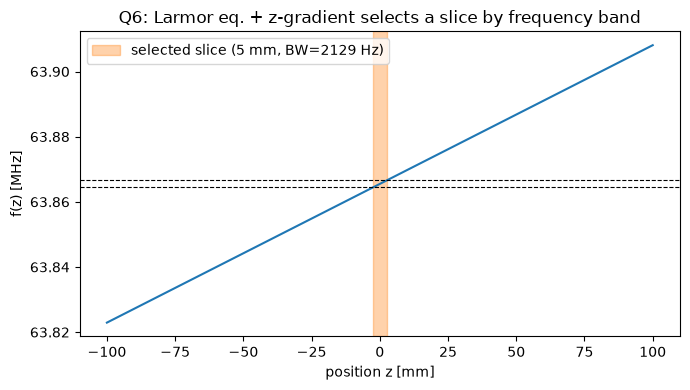

In [5]:
gamma_bar = 42.577e6     # Hz/T
B0, Gz = 1.5, 10e-3      # T, T/m
z0, dz = 0.0, 5e-3       # m
z = np.linspace(-0.1, 0.1, 1000)
f_z = gamma_bar * (B0 + Gz * z)
f0 = gamma_bar * (B0 + Gz * z0)
BW = gamma_bar * Gz * dz

plt.figure(figsize=(7, 4))
plt.plot(z * 1e3, f_z / 1e6, "tab:blue")
plt.axvspan((z0 - dz / 2) * 1e3, (z0 + dz / 2) * 1e3, color="tab:orange", alpha=0.35,
            label=f"selected slice ({dz*1e3:.0f} mm, BW={BW:.0f} Hz)")
plt.axhline((f0 - BW / 2) / 1e6, color="k", ls="--", lw=0.8)
plt.axhline((f0 + BW / 2) / 1e6, color="k", ls="--", lw=0.8)
plt.xlabel("position z [mm]"); plt.ylabel("f(z) [MHz]")
plt.title("Q6: Larmor eq. + z-gradient selects a slice by frequency band")
plt.legend(); plt.tight_layout(); plt.show()

## Q7 — Damadian (1971): which relaxation rate was statistically significant, which two were measured, and how do they differ?

In Damadian's *Science* paper “Tumor detection by nuclear magnetic resonance,” the two relaxation
times measured were:
- **$T_1$ — the spin–lattice (longitudinal) relaxation time**, and
- **$T_2$ — the spin–spin (transverse) relaxation time**.

Both were found to be **elevated in tumor tissue**, and the differences between malignant and normal
tissue were **statistically significant** (the paper reports $p<0.01$ for essentially all normal
tissues; the longer $T_1$ of the tumors is the headline result used to *distinguish* malignant from
normal tissue).

**How they differ physically (loss of spin energy of a spinning proton):**
- $T_1$ (**spin–lattice**) is the time for the spin to **give its energy back to the surrounding
  lattice/molecular environment**, recovering longitudinal magnetization. It is an *energy-exchange*
  process with the surroundings.
- $T_2$ (**spin–spin**) is the time for spins to **lose phase coherence with each other** (mutual
  dephasing), decaying the transverse magnetization. It involves *no net energy loss to the
  lattice* — only loss of phase/order among the spins. (Always $T_2 \le T_1$.)

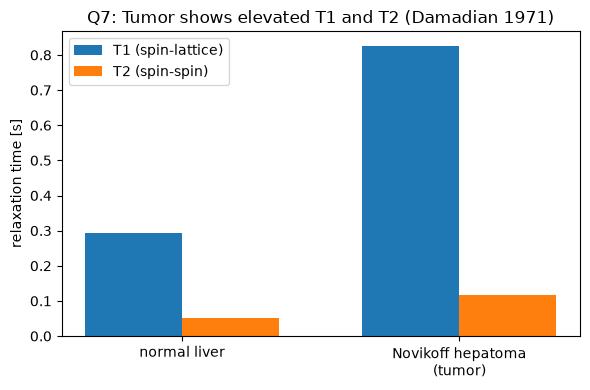

In [6]:
# Damadian-style relaxation times (seconds): tumor vs normal
labels = ["normal liver", "Novikoff hepatoma\n(tumor)"]
T1_vals = [0.293, 0.826]
T2_vals = [0.050, 0.118]
x = np.arange(len(labels)); w = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(x - w / 2, T1_vals, w, label="T1 (spin-lattice)", color="tab:blue")
ax.bar(x + w / 2, T2_vals, w, label="T2 (spin-spin)",   color="tab:orange")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("relaxation time [s]")
ax.set_title("Q7: Tumor shows elevated T1 and T2 (Damadian 1971)")
ax.legend(); plt.tight_layout(); plt.show()